In [2]:
import os

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D

In [4]:
current_path = os.getcwd()

In [5]:
os.listdir(current_path)

['cats', 'cat_dog.ipynb', 'dogs']

In [6]:
current_path = r'c:\\Users\\disha\\OneDrive\\Desktop\\Data Science\\Deep Learning\\CNN'
cat_path = os.path.join(current_path, 'Data', 'images', 'cats')
print("Total cat images:", len(os.listdir(cat_path)))


Total cat images: 349


In [7]:
images_path=os.path.join(current_path,'Data','images')

In [8]:
os.listdir(images_path)

['cats', 'cat_dog.ipynb', 'dogs']

In [9]:
# path_dict={'cats':[], 'dogs':[]}
# for dir in os.listdir(images_path):      
#     directory_path=os.path.join(images_path, dir)
#     for images in os.listdir(directory_path):
#         path_dict[dir].append(os.path.join(directory_path, images))
path_dict = {'cats': [], 'dogs': []}

for dir in os.listdir(images_path):
    directory_path = os.path.join(images_path, dir)
    if os.path.isdir(directory_path):  # ✅ Only proceed if it's a folder
        for image in os.listdir(directory_path):
            path_dict[dir].append(os.path.join(directory_path, image))
  

In [10]:
from PIL import Image


In [11]:
path_dict['cats'][0]

'c:\\\\Users\\\\disha\\\\OneDrive\\\\Desktop\\\\Data Science\\\\Deep Learning\\\\CNN\\Data\\images\\cats\\cat_1.jpg'

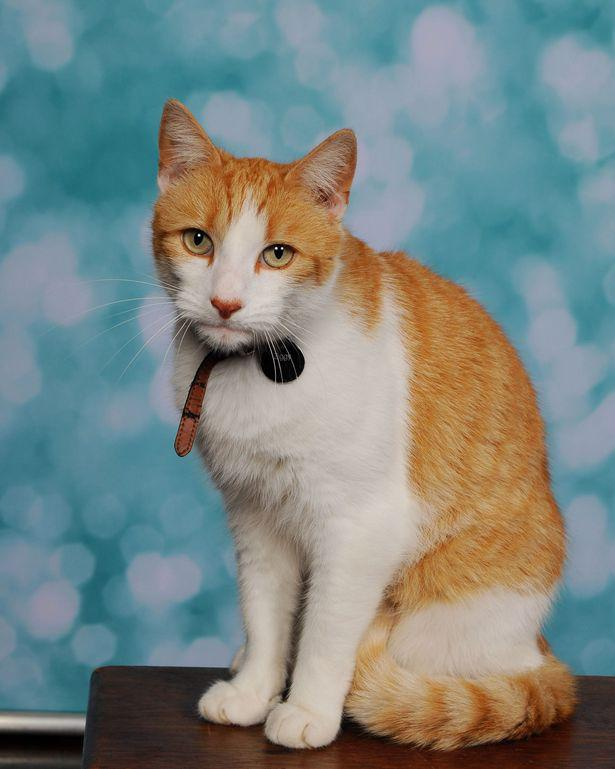

In [12]:
Image.open(path_dict['cats'][0])

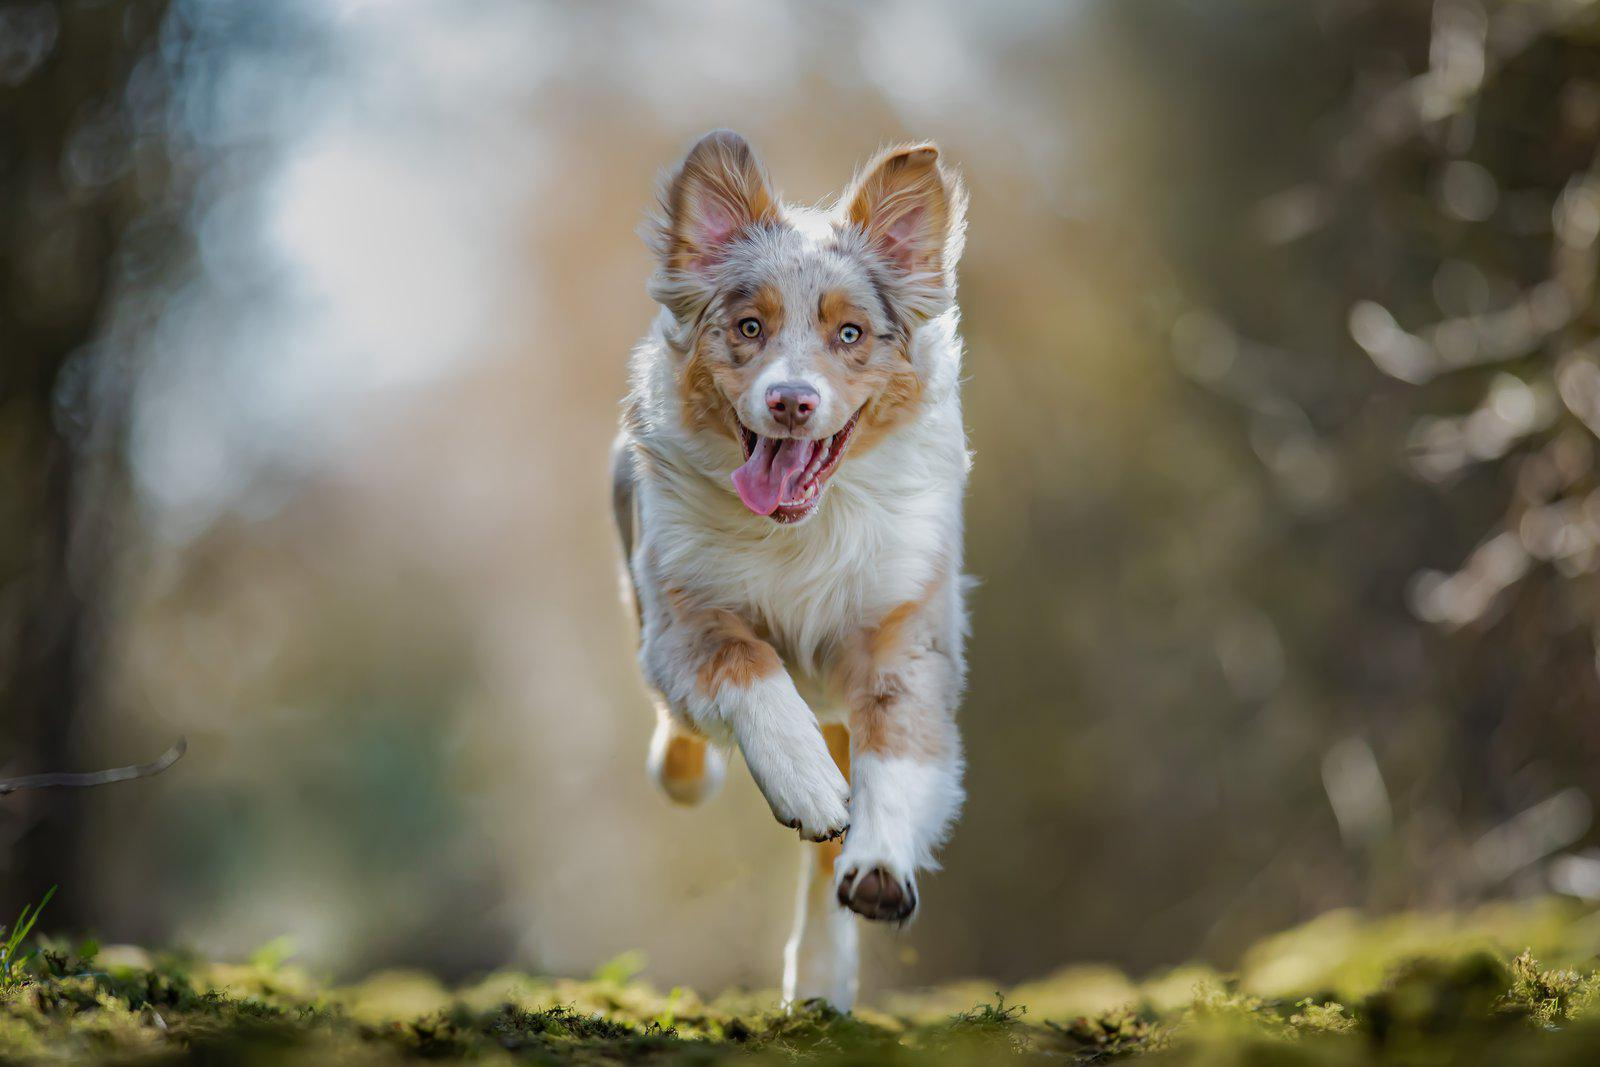

In [13]:
Image.open(path_dict['dogs'][0])

In [14]:
import cv2

In [15]:
path_dict.keys()

dict_keys(['cats', 'dogs'])

In [16]:
img_arr_list=[]
labels=[]

In [ ]:
for key, val in path_dict.items():
    for path in val:
        img = cv2.imread(path)
        resized_img = cv2.resize(img, (224, 224))  
        img_arr_list.append(resized_img)
        labels.append(key)

In [19]:
img_arr_list

[array([[[156, 141,  92],
         [159, 144, 102],
         [159, 145, 112],
         ...,
         [152, 142,  75],
         [156, 144,  80],
         [160, 148,  84]],
 
        [[151, 136,  87],
         [155, 140,  97],
         [157, 143, 107],
         ...,
         [151, 140,  75],
         [154, 142,  77],
         [157, 145,  81]],
 
        [[150, 136,  86],
         [155, 141,  96],
         [155, 140, 102],
         ...,
         [151, 139,  75],
         [153, 141,  77],
         [157, 145,  81]],
 
        ...,
 
        [[ 81,  90,  99],
         [ 77,  86,  95],
         [ 79,  88,  97],
         ...,
         [ 37,  42,  60],
         [ 39,  42,  57],
         [ 40,  43,  58]],
 
        [[ 52,  59,  59],
         [ 54,  60,  61],
         [ 51,  57,  58],
         ...,
         [ 40,  44,  59],
         [ 42,  45,  60],
         [ 43,  46,  61]],
 
        [[ 37,  41,  36],
         [ 33,  37,  34],
         [ 35,  38,  35],
         ...,
         [ 40,  43,  56],
  

In [20]:
img_arr_list=np.array(img_arr_list)

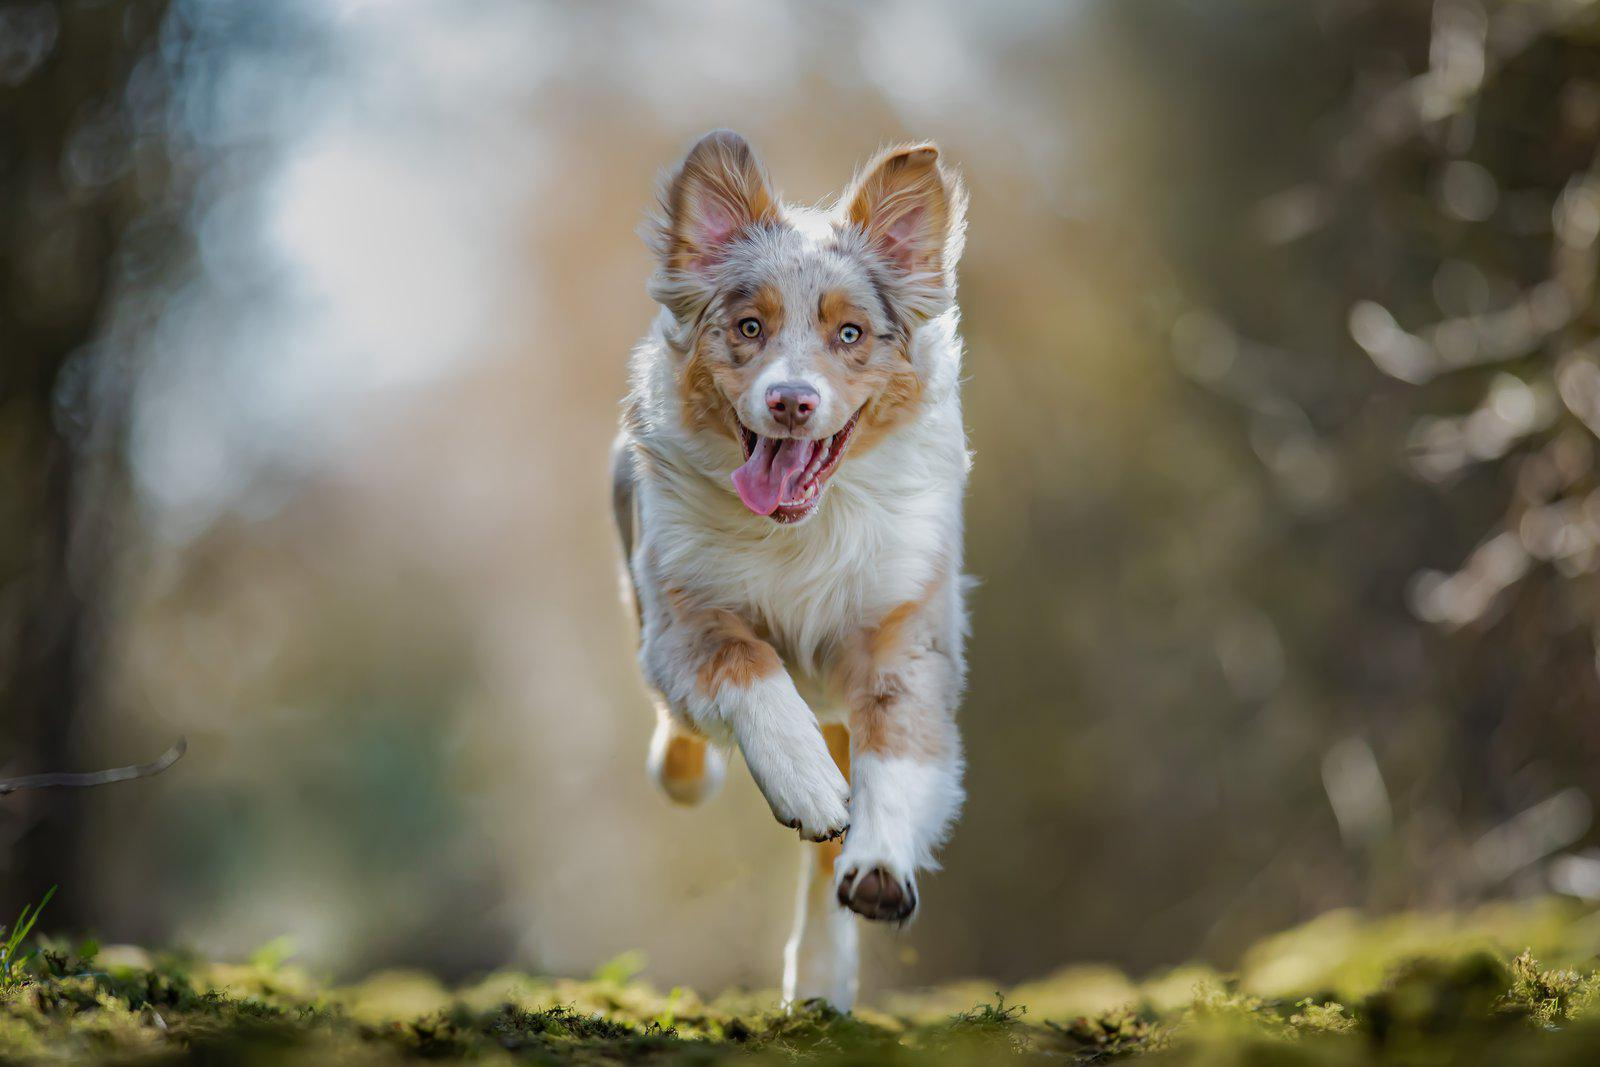

In [32]:
Image.open(path_dict['dogs'][0])

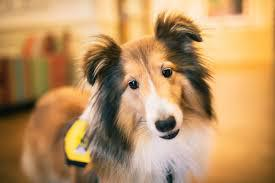

In [33]:
Image.open(path_dict['dogs'][12])

In [21]:
img_arr_list.shape

(697, 224, 224, 3)

In [22]:
labels = np.array(labels)

In [23]:
labels.shape

(697,)

In [24]:
labels

array(['cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',
      

In [25]:
# from sklearn.preprocessing import OneHotEncoder
# ohe= OneHotEncoder()
# labels=ohe.fit_transform([labels])

In [26]:
# labels = np.array(labels)

In [27]:
# labels

In [34]:
encoded_labels = np.array([0 if label == 'cats' else 1 for label in labels])

print(encoded_labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 

In [35]:
encoded_labels.shape

(697,)

In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(img_arr_list, encoded_labels, test_size=0.2)

In [39]:
x_train=x_train/255
x_test=x_test/255


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
model = Sequential([
    Conv2D(128, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


c:\Users\disha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4713 - loss: 149.9356
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5046 - loss: 0.9711
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7048 - loss: 0.5693
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8226 - loss: 0.4092
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9164 - loss: 0.2612
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9345 - loss: 0.2545
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9169 - loss: 0.2085
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9681 - loss: 0.1343
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9712 - loss: 0.1151
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9746 - loss: 0.1009


In [41]:
pred=model.predict(x_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step


In [42]:
pred

array([[0.5246353 ],
       [0.50729996],
       [0.5074309 ],
       [0.50815964],
       [0.48845586],
       [0.5045629 ],
       [0.5101235 ],
       [0.50790834],
       [0.5210632 ],
       [0.50316346],
       [0.50507104],
       [0.49134654],
       [0.5016564 ],
       [0.52518094],
       [0.49466494],
       [0.5166943 ],
       [0.50592935],
       [0.50297344],
       [0.50171137],
       [0.473763  ],
       [0.49305505],
       [0.5055229 ],
       [0.5126773 ],
       [0.49589312],
       [0.50454676],
       [0.5093371 ],
       [0.50525403],
       [0.4981445 ],
       [0.50937754],
       [0.50769794],
       [0.48835808],
       [0.50446534],
       [0.49667537],
       [0.48400238],
       [0.49694514],
       [0.51210535],
       [0.504109  ],
       [0.48676357],
       [0.4995643 ],
       [0.50642216],
       [0.496137  ],
       [0.5032612 ],
       [0.5095985 ],
       [0.5127279 ],
       [0.5103409 ],
       [0.50644964],
       [0.5042336 ],
       [0.496

In [43]:
pred=(pred > 0.5).astype(int)

In [44]:
pred

array([[1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
    

In [45]:
y_test

array([1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1])

In [46]:
model.save('cat_dog_model.h5')